<a href="https://colab.research.google.com/github/Skhelshiaty/CS4082-Machine-Learning-Labs/blob/main/Lab7_ML_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Lab 7 – Version 2

## Part 1: Function Design

The goal of this lab is to build a reusable function that compares multiple machine learning models using the same training and testing data.

The function will train each model, make predictions on the test set, and return the evaluation results in a structured table.

## Task 1: Model Comparison Function

The function below accepts a dictionary of machine learning models, trains each model using the training data, predicts the labels for the test data, and evaluates the results using Accuracy, Precision, Recall, and F1-score.

In [20]:
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

def compare_models(models, X_train, y_train, X_test, y_test):
    results = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1-score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
        })

    return pd.DataFrame(results)

## Creating the Models

A dictionary of different machine learning models is created. These models will be passed to the comparison function.

We define a set of machine learning models to compare their performance.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

## Dataset and Splitting
We load the dataset and split it into training and testing sets.

In [22]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Running the Model Comparison

In [23]:
results_df = compare_models(models, X_train, y_train, X_test, y_test)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,SVM,1.0,1.0,1.0,1.0
4,KNN,1.0,1.0,1.0,1.0
5,Naive Bayes,1.0,1.0,1.0,1.0


## Sorting Results

In [24]:
results_df_sorted = results_df.sort_values(by="F1-score", ascending=False)
results_df_sorted

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,SVM,1.0,1.0,1.0,1.0
4,KNN,1.0,1.0,1.0,1.0
5,Naive Bayes,1.0,1.0,1.0,1.0


## Task 2: Model Comparison Results

The results show that different models perform differently on the dataset.

The model with the highest F1-score provides the best balance between precision and recall.

## Task 3: Best Model Selection

The best model is selected based on the highest F1-score.

In [25]:
best_model = results_df_sorted.iloc[0]
best_model

,0
Model,Logistic Regression
Accuracy,1.0
Precision,1.0
Recall,1.0
F1-score,1.0


#Print nicely

In [26]:
print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1-score:", best_model["F1-score"])

Best Model: Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


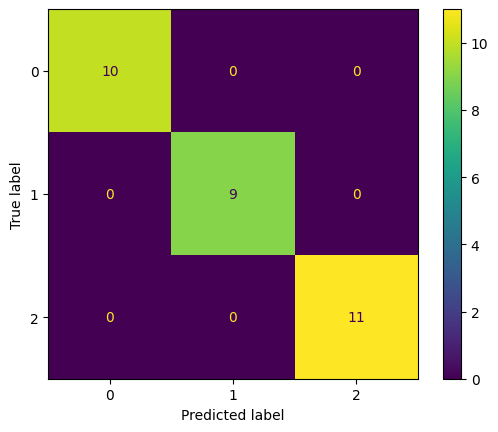

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_name = best_model["Model"]
model = models[model_name]

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()